# Introduction to Regression With Neural Networks in TensorFlow
* There are many definitions for a regression problem but in our case, we are going to simply it: Predicting a numerical variable based on some other combinaiton of variables, even shorter... predicting a number.


In [141]:
import tensorflow as tf


# Creating data to view and fit

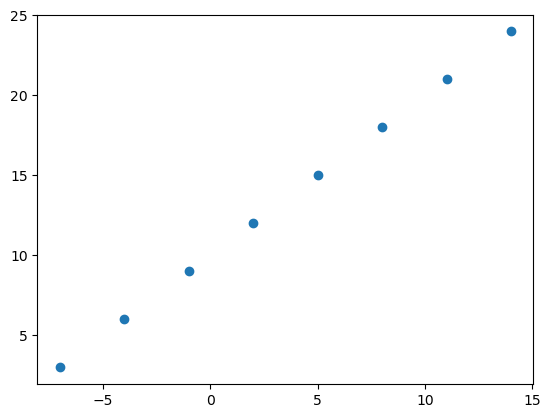

In [142]:
import numpy as np
import matplotlib.pyplot as plt

#Create features
X = np.array([-7.0,-4.0,-1.0,2.0,5.0,8.0,11.0,14.0])

# Create labels
y = np.array([3.0, 6.0,9.0,12.0,15.0,18.0,21.0,24.0])

# Visualize
plt.scatter(X,y)

In [143]:
 y== X+10

array([ True,  True,  True,  True,  True,  True,  True,  True])

 ## Input and Output shapes
 

In [144]:
tf.shape(X)

<tf.Tensor: shape=(1,), dtype=int32, numpy=array([8])>

In [145]:
tf.shape(y)

<tf.Tensor: shape=(1,), dtype=int32, numpy=array([8])>

In [146]:
# Create a demo tensor for our housing price prediction problem
house_info = tf.constant(["bedroom","bathroom","garage"])
house_price = tf.constant([939700])
#house_info, house_price

In [147]:
#X.ndim

In [148]:
#X[0].ndim

In [149]:
# Turn our Numpy arrays into tensors with dtye float32
X = tf.cast(tf.constant(X),dtype = tf.float32)
y = tf.cast(tf.constant(y),dtype =tf.float32)
#X,y

In [150]:
input_shape = X[0].shape
output_shape = y[0].shape
#input_shape,output_shape

In [151]:
#plt.scatter(X,y)

## Steps in modelling with tensorflow
* **Creating a model:** - define the input and output layers, as well as the hidden layers of a deep learning model
* **Compiling a model:** - define the loss function (in other words, the function which tells our model how wrong it is) and the optimizer (tells our models how to improve the patterns its learning) and evaluation metrics (what we can use to interpret the performance of our model).
* **Fitting a model:** - letting the model try to find patterns between X & y (features and labels). 

In [152]:
# Optionally, the first layer can receive an "input_shape" argument:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(8,input_shape=(16,)))
# Afterwards, we do automatic shape inference:
model.add(tf.keras.layers.Dense(4))

model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(8,input_shape=(16,)))
...

model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(1))
model.add(tf.keras.layers.Dense(1))

In [153]:
import tensorflow as tf


# Set random seed
tf.random.set_seed(42)

# 1. Create a model using the sequential  API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model 
model.compile(loss = tf.keras.losses.mae, # mae is short for mean absolute error
              optimizer = tf.keras.optimizers.SGD(), # sgd is short for stochastic gradient desenct
              metrics = ["mae"]
              )
#3. Fit the model
model.fit(tf.expand_dims(X,axis=-1),y,epochs=5,verbose=0)

In [154]:
# Check out X and y
#X,y

In [155]:
# Try and make a prediction using our model
y_pred = model.predict([17.0])
#y_pred

1/1 [==============================] - 0s 52ms/step


In [156]:
#y_pred +10

## Improving pur Model
We can improve our model, by altering the steps  we took to create a model.
1. **Creating a model** - here we might add more layers, increase the number of hidden units/neurons within each of the hidden layers, change the activation function of each layer.
2. **Compiling a model** - here we might change the optimazation function or perhaps the **learning rate** of the optimazation function.
3. **Fitting a model** - here we might fit a model for more  **epochs** (leave it training for longer) or on more data (give the model more expamples to learn from).

In [157]:
# Lets rebuild our model

# 1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
# 2. Compile the model
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics=["mae"]
              )
# 3. Fit the model (this time we'll train for longer)
model.fit(tf.expand_dims(X,axis=-1),y,epochs= 100,verbose=0)

In [158]:
# Remind ourselves of the data
#X,y

In [159]:
# Let's see if our model's prediction has improved...
y_pred2 = model.predict([17.0])
#y_pred2

1/1 [==============================] - 0s 49ms/step


In [160]:

# TensorFlow hangi cihazları görüyor?
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

# Default device ne?
print("Is GPU available?", tf.test.is_gpu_available(cuda_only=True))

# Hangi device'da çalışıyorsun (örnek: GPU:0 ya da CPU:0)
print("Default device:", tf.test.gpu_device_name())

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Is GPU available? True
Default device: /device:GPU:0


In [161]:
# Lets rebuild our model (this time with optimizer adam with lr = 0.00001)

# 1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
# 2. Compile the model
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.Adam(lr=0.00001),
              metrics=["mae"]
              )
# 3. Fit the model (this time we'll train for longer)
model.fit(tf.expand_dims(X,axis=-1),y,epochs= 100,verbose=0)

C:\Users\Eren\AppData\Roaming\Python\Python310\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [162]:
# Remind ourselves of the data
# X,y

In [163]:
# Let's see if our model's prediction has improved...
y_pred3 = model.predict([17.0])
# y_pred3

1/1 [==============================] - 0s 48ms/step


In [164]:
# Lets rebuild our model (this time with 2 hidden layers)

# 1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)

])
# 2. Compile the model
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics=["mae"]
              )
# 3. Fit the model (this time we'll train for longer)
model.fit(tf.expand_dims(X,axis=-1),y,epochs= 100,verbose=0)

In [165]:
# Remind ourselves of the data
#X,y

In [166]:
# Let's see if our model's prediction has improved...
y_pred4 = model.predict([17.0])
#y_pred4

1/1 [==============================] - 0s 54ms/step


In [167]:
# Lets rebuild our model (this time with 5 hidden layers & optimizer Adam (lr =0.2) )

# 1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1),


    

])
# 2. Compile the model
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.Adam(lr=0.2),
              metrics=["mae"]
              )
# 3. Fit the model (this time we'll train for longer)
model.fit(tf.expand_dims(X,axis=-1),y,epochs= 100,verbose=0)

In [168]:
# Remind ourselves of the data
# X,y

In [169]:
# Let's see if our model's prediction has improved...
y_pred5 = model.predict([17.0])
# y_pred5

1/1 [==============================] - 0s 65ms/step


In [170]:
# Let's see if we can make another improvement to our model 

#1. Create the model (this time with an extra hidden layer with 100 hidden units)

# 1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(100),



    

])
# 2. Compile the model
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics=["mae"]
              )
# 3. Fit the model (this time we'll train for longer)
model.fit(tf.expand_dims(X,axis=-1),y,epochs= 100,verbose=0)


In [171]:
# Remind ourselves of the data
# X,y

In [172]:
# Let's see if our model's prediction has improved...
y_pred6 = model.predict([17.0])
# y_pred6

1/1 [==============================] - 0s 56ms/step


In [173]:
# Let's see if we can make another improvement to our model 

#1. Create the model (this time with an extra hidden layer with 100 hidden units)

# 1. Create the model

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(100),
])

# 2. Compile the model 
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics =["mae"]
              )

# 3. Fit the model 
model.fit(tf.expand_dims(X,axis=-1),y,epochs =100,verbose=0)


In [174]:
# Let's see if we can make another improvement to our model 

#1. Create the model (this time with an extra hidden layer with 100 hidden units)

# 1. Create the model

model  = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation = "relu"),
    tf.keras.layers.Dense(1)
])

#2. Compile the model

model.compile(loss = tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics =["mae"])

# Fit the model
model.fit(tf.expand_dims(X,axis=-1),y,epochs=100,verbose=0)


In [175]:
# Let's remind ourselves of the data
# X,y

In [176]:
# Let's try to make a prediction
model.predict([17.0])

1/1 [==============================] - 0s 53ms/step


array([[32.30353]], dtype=float32)

# Evaluating a Model
 In practice, a typical workflow you'll go thorugh when building neural network is:

 Build a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak it...

 When it comes to evaluation... there are 3 words you should memorize:
"Visualize, Visualize, Visualize"
 It's a good idea to visualize:
 * The data - what data are we working with? What does it look like? 
 * The model itself - what does our model look like?
 * The training of a model - how does a model perform while it learns
 * The predictions of the model - how do the predictions of a model line up againts the ground truth (the original labels)

In [177]:
# Make a bigger dataset
X = tf.range(-100,100,4)
# X

In [178]:
# Make labels for the dataset
y = X +10
# y

In [179]:
# Visualize the data
import matplotlib.pyplot as plt
# plt.scatter(X,y)

### The 3 sets...
* Training set - the model learns from this data, which is typically 70-80% of the total data you have available.
* Validation set - the model gets tuned on this data, which is typically 10-15% of the data available.
* Test set- the model gets evaluated on this data to test what is has learned, this set is typically 10-15% of the total data available.

In [180]:
# Check the lenght of how many samples we have
# len(X)

In [181]:
# Split the data into train and test sets
X_train  = X[:40] # first 40 are the training samples (80% of the data)
y_train = y[:40]


X_test = X[40:] # Last 10 are the training samples (20% of the data)
y_test = y[40:]

#len(X_train), len(X_test),len(y_train), len(y_test)

# Visualizing the data
Now we've got our data in training and test sets, let's visualize it again!

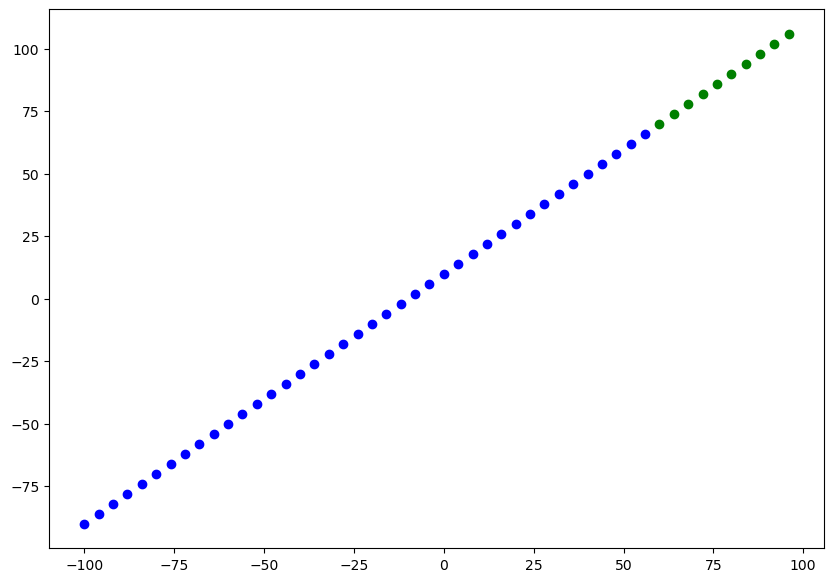

In [182]:
plt.figure(figsize=(10,7))
# Plot training data in blue
plt.scatter(X_train,y_train, c="b", label = "Training data")
# Plot test data in green
plt.scatter(X_test,y_test, c="g", label = "Testing data")
# Show a legend
#plt.legend()

In [183]:
# Let's have a look at how to build a neural network for our data
# 1. Create a model

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss =tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics="mae")

# 3. Fit the model

model.fit(tf.expand_dims(X_train,axis=-1),y_train,epochs=100,verbose=0)

In [184]:
# model.summary()
#from sklearn.model_selection import train_test_split


In [185]:
# X[0],y[0]

In [186]:
# Let's create a model which builds automatically by defining the input_shape argument.
tf.random.set_seed(42)

# 1. Create a model (same as above)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10,input_shape=[1],name="input_layer"),
    tf.keras.layers.Dense(1,input_shape=[1],name="output_layer")
],name="model_1")

# 2.Compile the model
model.compile(loss= tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics =["mae"])
# 3. Fit the model

#model.fit(tf.expand_dims(X_train,axis=-1),y_train,epochs= 100)

In [187]:
# model.summary()

* **Total params** - total number of parameters in the model.
* **Trainable parameters** - these are the parameters (patterns) the model can update as it trains.
* **Non -trainable params** - These parameters aren't updated during training (this is typical when you bring in already learn patterns or parameters from other models during **trasfer learning**).

In [188]:
# Let's fit our model to the training data  
model.fit(tf.expand_dims(X_train,axis=-1),y_train,epochs =100,verbose=0)

In [189]:
from tensorflow.keras.utils import plot_model 
# plot_model(model = model, show_shapes=True)

In [190]:
# 1. Create a model 
tf.random.set_seed(42)
model1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1,input_shape=[1]),
    


],name="model_2")

# 2. Compile the model

model1.compile(loss=tf.keras.losses.mae,
               optimizer=tf.keras.optimizers.SGD(),
               metrics="mae")

# model1.summary()

In [191]:


# 3. Fit the model
model1.fit(tf.expand_dims(X_train,axis=-1),y_train,epochs=100,verbose=0)

In [192]:
#plot_model(model=model1,show_shapes=True)

# Visualizing our model's predictions
To visualize predictions, it's a good idea to plot them againts the ground truth labels.

Often you'll see this in the form of "y_test" or "y_true" versus "y_pred" (ground truth versus your model's predictions).

In [193]:
# Make some predictions
y_pred = model1.predict(X_test)
#y_pred

1/1 [==============================] - 0s 34ms/step


In [194]:
# y_test

**Note:** If you feel like you're going to reuse some kind of functionality in the future, it's good idea to turn it into a function.

In [195]:
# Lets create a plotting function
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data = X_test,
                     test_labels=y_test,
                     predictions= y_pred):
    
    """Plot training data, test data and compares predictions to ground truth labels."""
    plt.figure(figsize=(10,7))
    #Plot training data in blue
    plt.scatter(train_data,train_labels,c="b",label ="training data")
    # plot testing data in green
    plt.scatter(test_data,test_labels,c="g",label= "test data")
    # Plot model's predictions in red
    plt.scatter(test_data,predictions,c="r",label="predictions")
    # Show the legend
    plt.legend()
    


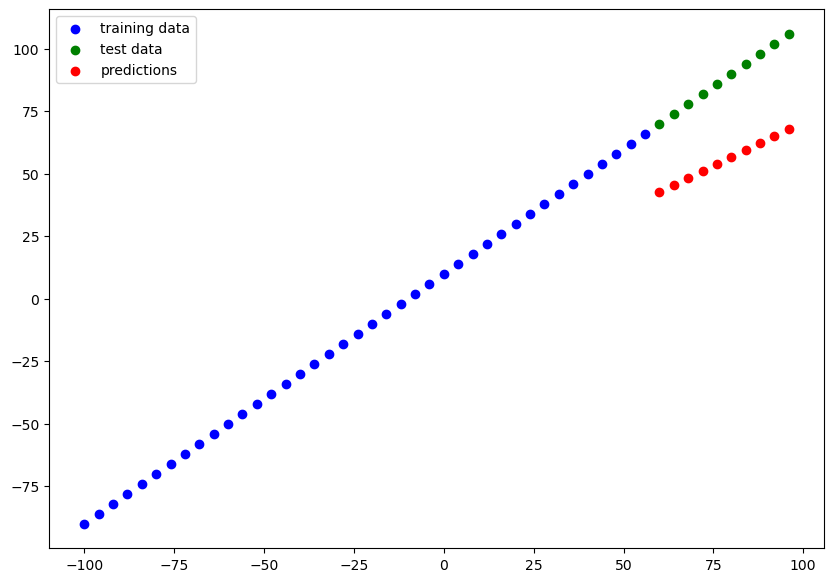

In [196]:
plot_predictions(train_data = X_train,
                 train_labels=y_train,
                 test_data=X_test,
                 test_labels=y_test,
                 predictions=y_pred)

# Evaluating Our Model's Predictions with Regression Evaluation Metrics
Depending on the problem you are working on there will be different evaluation metrics to evaluate your model's performance.

Since we're working on a regression, two of the main metrics:
* MAE - mean absolute error, "on average, how wrong is each of my model's predictions"
* MSE - mean square error, "square the average errors"

In [197]:
# Evaluate the model on the test 
model1.evaluate(X_test,y_test)

1/1 [==============================] - 0s 79ms/step - loss: 32.6451 - mae: 32.6451


[32.64510726928711, 32.64510726928711]

In [198]:
# y_pred


In [199]:
# y_test

In [200]:
# Calculate the mean absolute error
# tf.keras.losses.mae(y_test,y_pred)

In [201]:
# Calculate the mean absolute error
# tf.metrics.mean_absolute_error(y_test,y_pred)

In [202]:
mae = tf.metrics.mean_absolute_error(tf.expand_dims(y_test,axis=-1),tf.constant(y_pred))
# mae
#tf.math.reduce_mean(mae)

In [203]:
# y_pred, y_pred.shape

In [204]:
# y_test

In [205]:
mae = tf.metrics.mean_absolute_error(y_test,tf.squeeze(tf.constant(y_pred)))
# mae

In [206]:
# Calculate the mean absolute error
mae2 = tf.metrics.mean_absolute_error(y_true=y_test,
                                      y_pred=tf.squeeze(y_pred))
# mae2

In [207]:
# Calculate the mean square error
mse = tf.metrics.mean_squared_error(y_true=y_test,
                                    y_pred=tf.squeeze(y_pred))
# mse


In [208]:
mse2 = tf.keras.losses.mse(y_true=y_test,
                                    y_pred=tf.squeeze(y_pred))
# mse2

In [209]:
# tf.keras.losses.huber(y_test,tf.squeeze(tf.constant(y_pred)))

In [210]:
# Make some functions to reuse MAE and MSE

def mae_f(y_true,y_pred):
    return tf.metrics.mean_absolute_error(y_true=y_test,y_pred=tf.squeeze(tf.constant(y_pred)))

def mse_f(y_true,y_pred):
    return tf.metrics.mean_squared_error(y_true=y_test,y_pred=tf.squeeze(tf.constant(y_pred)))

In [211]:
mae_f(y_true=y_test,
      y_pred=y_pred)

<tf.Tensor: shape=(), dtype=float32, numpy=32.645107>

In [212]:
mse_f(y_true=y_test,
      y_pred=y_pred)

<tf.Tensor: shape=(), dtype=float32, numpy=1078.1649>

# Running Experiments to Improve Our Model

Build a model -> Compile it -> fit it -> Evaluate it -> Tweak it -> Fit it -> Evaluate it -> Tweak it -> Fit it -> Evaluate it -> Tweak it -> Fit it.....

1. Get more data - get more examples for your model to train on (more opportunities to learn patterns or relationships between features and labels).
2. Make your model larger (using a more complex model,) -this might come in the form of more layers or more hidden units in each layer.
3. Train for longer - give your model more chance to find patterns in the data.

Let's do 3 modelling experiments

1. 'model_a' - same as the original model, 1 layer, trained for 100 epochs.
2. 'model_b' - 2 layers, trained for 100 epochs
3. 'model_c' 2 layers, trained for 500 epochs
4. 'model_d' 2 layers, double times hidden unit, 100 epochs
5. 'model_e' 2 layers, double times hidden unit, 500 epochs

In [213]:
# X_train, y_train

In [214]:
# Set random seed
tf.random.set_seed(42)
# Build model_a

model_a = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model

model_a.compile(loss = tf.keras.losses.mae,
                optimizer = tf.keras.optimizers.SGD(),
                metrics= ["mae"])
# 3. Fit the model 
model_a.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=100,verbose=0)

1/1 [==============================] - 0s 35ms/step


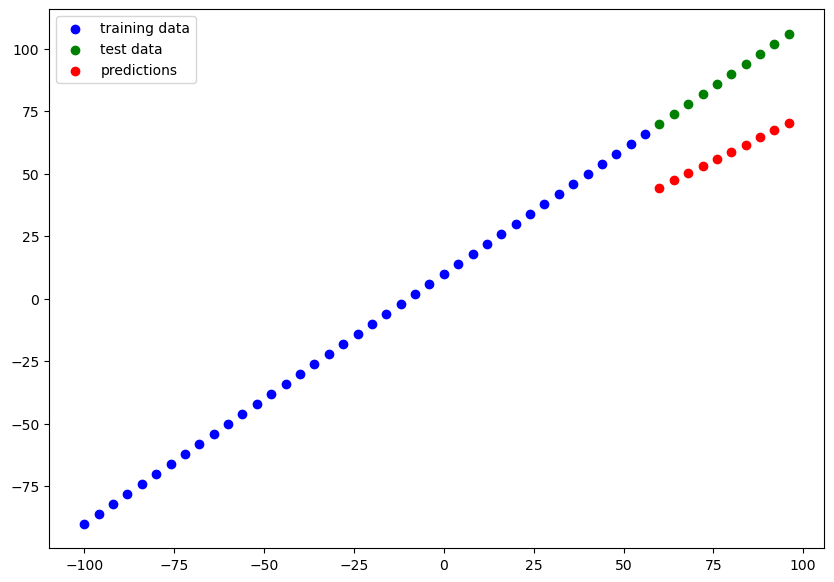

In [215]:
# Make and plot prediction model_a 

y_preds_a = model_a.predict(X_test)
plot_predictions(predictions = y_preds_a)

In [216]:
# Calculate model_a evaluation metrics
mae_a = mae_f(y_true=y_test,y_pred=y_preds_a)
mse_a = mse_f(y_test,y_pred=y_pred)
# mae_a,mse_a

# Build model_b


In [217]:
# 2 dense layers trained for 100 epochs
# Set random seed
tf.random.set_seed(42)
# 1. Create the model

model_b = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model 
model_b.compile(loss= tf.keras.losses.mae,
                optimizer= tf.keras.optimizers.SGD(),
                metrics =["mse"])

# Fit the model
model_b.fit(tf.expand_dims(X_train,axis=-1),y_train,epochs=100,verbose=0)





In [218]:
# X_test, y_test

1/1 [==============================] - 0s 39ms/step


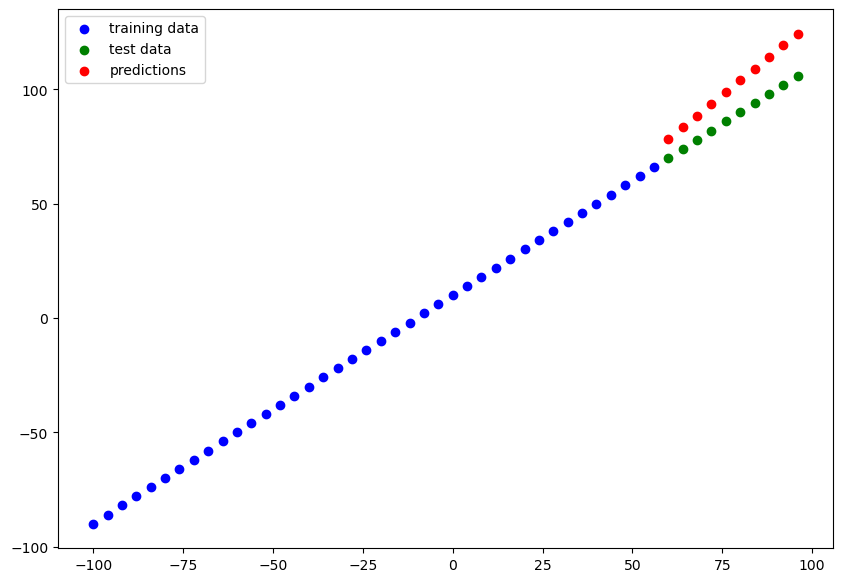

In [219]:
# Make and plot prediction model_a 

y_preds_b = model_b.predict(X_test)
plot_predictions(predictions = y_preds_b)


In [220]:

# y_preds_b.shape,y_preds_b, X_test.shape


In [221]:
mae_b = mae_f(y_true=y_test,y_pred=y_preds_b)
mse_b = mse_f(y_test,y_pred=y_preds_b)

# mae_b,mse_b

# Build Model_C
2 layers, trained for 500 epochs

In [222]:
# set random seed
tf.random.set_seed(42)

# 1. Create a model
model_c = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

 # 2. Compile the model
model_c.compile(loss= tf.keras.losses.mae,
                 optimizer=tf.keras.optimizers.SGD(),
                 metrics=["mse"])

# 3.  Fit the model
model_c.fit(tf.expand_dims(X_train,axis=-1),y_train,epochs= 500,verbose=0)


1/1 [==============================] - 0s 38ms/step


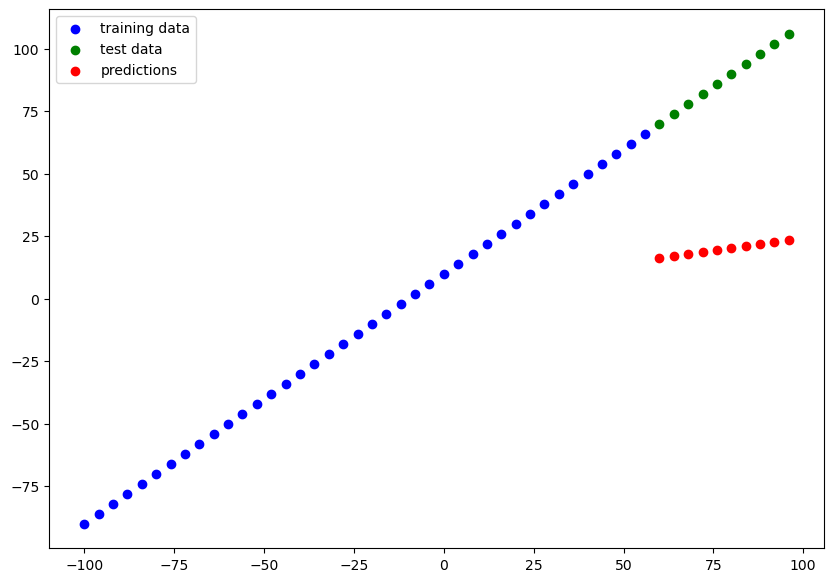

In [223]:
# Make and plot prediction model_c
y_preds_c= model_c.predict(X_test)
plot_predictions(predictions=y_preds_c)




In [224]:
mae_c = mae_f(y_true=y_test,y_pred=y_preds_c)
mse_c = mse_f(y_true=y_test,y_pred=y_preds_c)
# mae_c,mse_c

# Comparing the results of our experiments
We've run a few experiments, let's compare the results
* **Note:** You wan to start with small experiments (smal models) and make sure they work, and then increase their scale when necessary.

In [225]:
#tf.shape(mae_a)
print(mae_a.numpy())
print(mse_a.numpy())
#pd.__version__

30.619007
1078.1649


In [226]:
# Let's compare our model's results using a pandas DataFrame
import pandas as pd

model_results = [["model_a",mae_a.numpy(),mse_a.numpy()],
                 ["model_b",mae_b.numpy(),mse_b.numpy()],
                 ["model_c",mae_c.numpy(),mse_c.numpy()]]

all_results= pd.DataFrame(model_results,columns= ["model","mae","mse"])
all_results


,model,mae,mse
0,model_a,30.619007,1078.164917
1,model_b,13.360501,188.634644
2,model_c,68.062912,4717.490723


Looks like mode_2 performed the best...

In [227]:
# model_b.summary()

* **Note:** One of your main goal should be minimize the time between your experiments. The more experiments you do, the more things you figure out which don't work and in turn, get closer to figuring out what does work. Remember the machine learning practioner's motto: "Experiment, experiment, experiment".

## Tracking your experiments 

One really good habit in machine learning modelling is to track the results of your experiments.

And when doing so, it can be tedious if you're running lots of experiments.

Luckily, there are tools to help us!

* **Resource:** As you build more models, you'll want to look into using:
 *TensorBoard - a component of the TensorFlow library to help track modelling experiments
 * Weights & Biases - a tool for tracking all kinds of ML experiments (plugs directly into TensorBoard)

## Saving Our Models

Saving our models allows us to use them outside of wherever they were trained, such as in a web application or mobile app.

There are two main formats we can save our model's too:
1. The Savedmodel format
2. The HDF5 format

In [228]:
# Save model using the SavedModel format
model_b.save("best_model_SavedModel_format")

INFO:tensorflow:Assets written to: best_model_SavedModel_format\assets


In [229]:
# ALT-1
# Save model using the HDF5 format
model_b.save("best_model_HDF5_format.h5")
#ALT-2
# Yeni TensorFlow sürümleri artık .h5 yerine .keras uzantılı modeli öneriyor.
# model_b.save("best_model.keras")

# ALT-3
# model_b.save_weights("best_model_weights.h5")


In [230]:
"""import tensorflow as tf
from tensorflow import keras
from keras_tuner import RandomSearch

def build_model(hp):
    model = keras.Sequential()
    # Katman sayısını ve nöron sayısını otomatik arıyor
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(keras.layers.Dense(
            units=hp.Int(f'units_{i}', min_value=4, max_value=128, step=8),
            activation='relu'
        ))
    model.add(keras.layers.Dense(1))
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
        ),
        loss='mae',
        metrics=['mae']
    )
    return model

# Tuner başlat
tuner = RandomSearch(
    build_model,
    objective='val_mae',
    max_trials=5,
    executions_per_trial=2,
    directory='my_dir',
    project_name='auto_model_search'
)

# Eğitim
tuner.search(X_train, y_train, epochs=100, validation_split=0.2)

# En iyi modeli al
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparams = tuner.get_best_hyperparameters()[0]

print("✅ En iyi model:", best_model.summary())
print("📊 En iyi hyperparametreler:", best_hyperparams.values)
"""



'import tensorflow as tf\nfrom tensorflow import keras\nfrom keras_tuner import RandomSearch\n\ndef build_model(hp):\n    model = keras.Sequential()\n    # Katman sayısını ve nöron sayısını otomatik arıyor\n    for i in range(hp.Int(\'num_layers\', 1, 3)):\n        model.add(keras.layers.Dense(\n            units=hp.Int(f\'units_{i}\', min_value=4, max_value=128, step=8),\n            activation=\'relu\'\n        ))\n    model.add(keras.layers.Dense(1))\n    model.compile(\n        optimizer=keras.optimizers.Adam(\n            hp.Choice(\'learning_rate\', [1e-2, 1e-3, 1e-4])\n        ),\n        loss=\'mae\',\n        metrics=[\'mae\']\n    )\n    return model\n\n# Tuner başlat\ntuner = RandomSearch(\n    build_model,\n    objective=\'val_mae\',\n    max_trials=5,\n    executions_per_trial=2,\n    directory=\'my_dir\',\n    project_name=\'auto_model_search\'\n)\n\n# Eğitim\ntuner.search(X_train, y_train, epochs=100, validation_split=0.2)\n\n# En iyi modeli al\nbest_model = tuner.get_be

## Loading in a saved model

In [231]:
# Load in the SavedModel format model
loaded_SavedModel_format = tf.keras.models.load_model("C:/Users/Eren/best_model_SavedModel_format")
loaded_SavedModel_format.summary()

Model: "sequential_31"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_60 (Dense)            (None, 10)                20        
                                                                 
 dense_61 (Dense)            (None, 1)                 11        
                                                                 
Total params: 31
Trainable params: 31
Non-trainable params: 0
_________________________________________________________________


In [232]:
model_b.summary()

Model: "sequential_31"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_60 (Dense)            (None, 10)                20        
                                                                 
 dense_61 (Dense)            (None, 1)                 11        
                                                                 
Total params: 31
Trainable params: 31
Non-trainable params: 0
_________________________________________________________________


In [233]:
# Compare mode_b predictions with SavedModel format model predictions
model_b_preds = model_b.predict(X_test)
loaded_SavedModel_format_preds = loaded_SavedModel_format.predict(X_test)

1/1 [==============================] - 0s 38ms/step


In [234]:
loaded_SavedModel_format_preds == model_b_preds

array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [235]:
mae_f(y_true= y_test,y_pred=model_b_preds) == mae_f(y_true= y_test,y_pred=loaded_SavedModel_format_preds)

<tf.Tensor: shape=(), dtype=bool, numpy=True>

In [236]:
# Load in a model using the .h5 format
loaded_h5_model = tf.keras.models.load_model("C:/Users/Eren/best_model_HDF5_format.h5")
loaded_h5_model.summary()

Model: "sequential_31"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_60 (Dense)            (None, 10)                20        
                                                                 
 dense_61 (Dense)            (None, 1)                 11        
                                                                 
Total params: 31
Trainable params: 31
Non-trainable params: 0
_________________________________________________________________


In [237]:
model_b.summary()

Model: "sequential_31"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_60 (Dense)            (None, 10)                20        
                                                                 
 dense_61 (Dense)            (None, 1)                 11        
                                                                 
Total params: 31
Trainable params: 31
Non-trainable params: 0
_________________________________________________________________


In [238]:
# Check to see if loaded .h5 model predictions  match model_b
model_b_preds = model_b.predict(X_test)
loaded_h5_model_preds = loaded_h5_model.predict(X_test)
model_b_preds == loaded_h5_model_preds

1/1 [==============================] - 0s 38ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

# Download a model (or any other file) from Google Colab

If

# A Larger Expample

In [239]:
X_train, y_train

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56])>,
 <tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66])>)

In [240]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Eren\.cache\kagglehub\datasets\mirichoi0218\insurance\versions\1


In [241]:
# Import required librares
# Read in the insurance dataset

insurance = pd.read_csv("C:/Users/Eren/OneDrive/Masaüstü/YAPAY ZEKA/COMPUTER VISION/tensorflow/insurance.csv")
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [242]:
# Let's try one-hot encode our DataFrame so it's all numbers  
insurance_one_hot = pd.get_dummies(insurance)
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0


In [243]:
# Create X & y values (feautres and labels)
# Create training and test sets
# Build a neural network (sort of like model_b above)

# First article

insurance_features = insurance_one_hot.drop("charges",axis=1)
insurance_target= insurance_one_hot["charges"]

# Second article
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(insurance_features,insurance_target,test_size=0.2, random_state=42)

X_train, y_train


(      age     bmi  children  sex_female  sex_male  smoker_no  smoker_yes  \
 560    46  19.950         2           1         0          1           0   
 1285   47  24.320         0           1         0          1           0   
 1142   52  24.860         0           1         0          1           0   
 969    39  34.320         5           1         0          1           0   
 486    54  21.470         3           1         0          1           0   
 ...   ...     ...       ...         ...       ...        ...         ...   
 1095   18  31.350         4           1         0          1           0   
 1130   39  23.870         5           1         0          1           0   
 1294   58  25.175         0           0         1          1           0   
 860    37  47.600         2           1         0          0           1   
 1126   55  29.900         0           0         1          1           0   
 
       region_northeast  region_northwest  region_southeast  region_southw

In [244]:

#  Third article - Build a neural network (sort of like model_b above)
# 1. Create a model
tf.random.set_seed(42)
insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model

insurance_model.compile(loss = tf.keras.losses.mae,
                        optimizer = tf.keras.optimizers.SGD(),
                        metrics = ["mae"])

# 3. Fit the model

insurance_model.fit(X_train,tf.expand_dims(y_train,axis=-1),epochs= 100)

Epoch 1/100
34/34 [==============================] - 0s 4ms/step - loss: 8641.0166 - mae: 8641.0166
Epoch 2/100
34/34 [==============================] - 0s 3ms/step - loss: 7858.7168 - mae: 7858.7168
Epoch 3/100
34/34 [==============================] - 0s 3ms/step - loss: 7526.3730 - mae: 7526.3730
Epoch 4/100
34/34 [==============================] - 0s 2ms/step - loss: 7767.0508 - mae: 7767.0508
Epoch 5/100
34/34 [==============================] - 0s 3ms/step - loss: 7685.5151 - mae: 7685.5151
Epoch 6/100
34/34 [==============================] - 0s 2ms/step - loss: 7591.1934 - mae: 7591.1934
Epoch 7/100
34/34 [==============================] - 0s 2ms/step - loss: 7559.8184 - mae: 7559.8184
Epoch 8/100
34/34 [==============================] - 0s 2ms/step - loss: 7808.6763 - mae: 7808.6763
Epoch 9/100
34/34 [==============================] - 0s 2ms/step - loss: 7494.8481 - mae: 7494.8481
Epoch 10/100
34/34 [==============================] - 0s 2ms/step - loss: 7685.5532 - mae: 7685.5532

In [245]:
# Check the result of the insurance model on test data
insurance_model.evaluate(X_test,y_test)


9/9 [==============================] - 0s 2ms/step - loss: 7034.2666 - mae: 7034.2666


[7034.2666015625, 7034.2666015625]

In [246]:
y_train.median(), y_train.mean()

(9575.4421, 13346.089736364489)

In [247]:
y_train.shape, X_train.shape

((1070,), (1070, 11))

Right now it looks like our model isn't performing too well.. let's try and improve it!

To (try) improve our model, we'll run 2 experiments:
1. add an extra layer with more hidden units and change the optimizer function
2. Train for longer
3. Adding 5 layers with same hidden units as model 1 and epoch
4. Adding 5 layers with same hidden units as model 1 and train for longer

In [248]:
# 2.nd model
# Set random seed
tf.random.set_seed(42)

# 1. create a model
insurance_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. compile the model 
insurance_2.compile(loss = tf.keras.losses.mae,
                    optimizer = tf.keras.optimizers.Adam(),
                    metrics =["mae"])

# 3. Fit the model
insurance_2.fit(X_train,tf.expand_dims(y_train,axis=-1),epochs= 100,verbose=1)



Epoch 1/100
34/34 [==============================] - 0s 3ms/step - loss: 13315.0957 - mae: 13315.0957
Epoch 2/100
34/34 [==============================] - 0s 3ms/step - loss: 13179.2598 - mae: 13179.2598
Epoch 3/100
34/34 [==============================] - 0s 3ms/step - loss: 12889.1279 - mae: 12889.1279
Epoch 4/100
34/34 [==============================] - 0s 4ms/step - loss: 12297.1895 - mae: 12297.1895
Epoch 5/100
34/34 [==============================] - 0s 4ms/step - loss: 11257.2295 - mae: 11257.2295
Epoch 6/100
34/34 [==============================] - 0s 3ms/step - loss: 9819.6855 - mae: 9819.6855
Epoch 7/100
34/34 [==============================] - 0s 3ms/step - loss: 8387.4414 - mae: 8387.4414
Epoch 8/100
34/34 [==============================] - 0s 3ms/step - loss: 7585.4419 - mae: 7585.4419
Epoch 9/100
34/34 [==============================] - 0s 3ms/step - loss: 7425.9067 - mae: 7425.9067
Epoch 10/100
34/34 [==============================] - 0s 4ms/step - loss: 7403.0317 - mae:

In [249]:
insurance_2.evaluate(X_test,y_test)

9/9 [==============================] - 0s 2ms/step - loss: 4912.2344 - mae: 4912.2344


[4912.234375, 4912.234375]

In [250]:
# 3.rd model
# set random seed
tf.random.set_seed(42)

# 1. Create a model 

insurance_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),
])

# 2. Compile the model 

insurance_3.compile(loss =tf.keras.losses.mae,
                    optimizer = tf.keras.optimizers.Adam(),
                    metrics= ["mae"]
                    )

# 3. Fit the model 

history = insurance_3.fit(X_train,tf.expand_dims(y_train,axis=-1),epochs= 200)

Epoch 1/200
34/34 [==============================] - 0s 3ms/step - loss: 13301.6953 - mae: 13301.6953
Epoch 2/200
34/34 [==============================] - 0s 3ms/step - loss: 13148.6416 - mae: 13148.6416
Epoch 3/200
34/34 [==============================] - 0s 3ms/step - loss: 12827.5752 - mae: 12827.5752
Epoch 4/200
34/34 [==============================] - 0s 3ms/step - loss: 12196.7246 - mae: 12196.7246
Epoch 5/200
34/34 [==============================] - 0s 3ms/step - loss: 11122.0293 - mae: 11122.0293
Epoch 6/200
34/34 [==============================] - 0s 3ms/step - loss: 9689.8818 - mae: 9689.8818
Epoch 7/200
34/34 [==============================] - 0s 3ms/step - loss: 8308.0771 - mae: 8308.0771
Epoch 8/200
34/34 [==============================] - 0s 3ms/step - loss: 7572.2686 - mae: 7572.2686
Epoch 9/200
34/34 [==============================] - 0s 3ms/step - loss: 7432.4624 - mae: 7432.4624
Epoch 10/200
34/34 [==============================] - 0s 3ms/step - loss: 7410.6431 - mae:

In [251]:
# Evaluate the model

insurance_3.evaluate(X_test,y_test)

9/9 [==============================] - 0s 2ms/step - loss: 3501.3728 - mae: 3501.3728


[3501.372802734375, 3501.372802734375]

Text(0.5, 0, 'epochs')

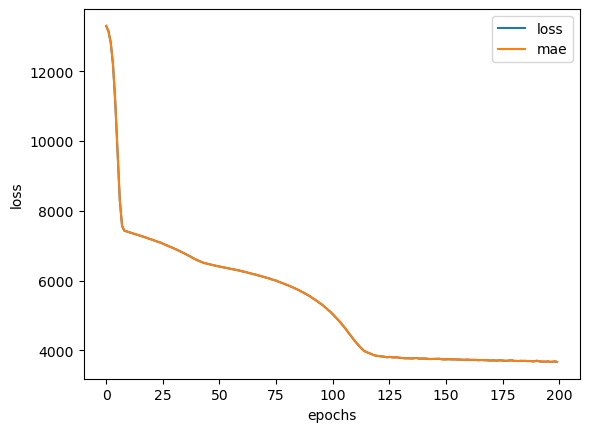

In [252]:
# Plot history (also known as loss curve or training curve )
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")


### **Question:** How long should you train for?

It depends. Really... it depends on the problem  you're working on. However, many people have asked this question before. So, TensorFlow has a solution.It is called the EarlyStoppingCallback,, which is a TensorFlow component you can add to your model to stop training or improving a certain metric.


## Preprocessing data (normalization and standardization)

In terms of scaling values, neural networks tend to prefer normalization.

In [253]:
insurance_one_hot

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,0,1,1,0,0,1,0,0
1334,18,31.920,0,2205.98080,1,0,1,0,1,0,0,0
1335,18,36.850,0,1629.83350,1,0,1,0,0,0,1,0
1336,21,25.800,0,2007.94500,1,0,1,0,0,0,0,1


<Axes: ylabel='Frequency'>

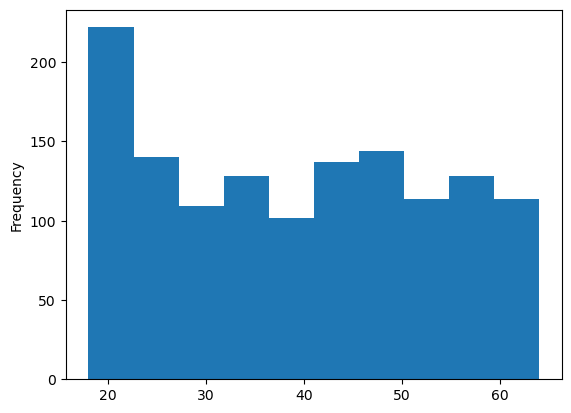

In [255]:
insurance_one_hot["age"].plot(kind = "hist")

<Axes: ylabel='Frequency'>

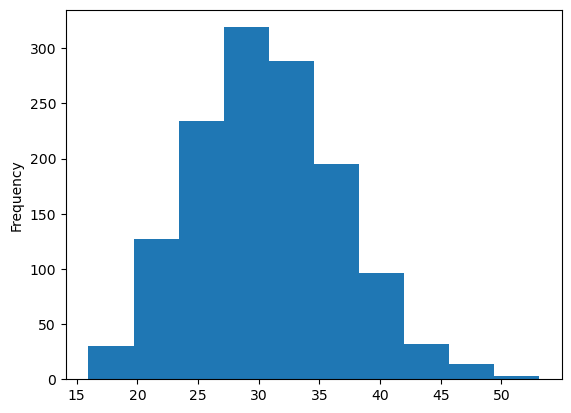

In [256]:
insurance_one_hot["bmi"].plot(kind = "hist")

In [257]:
insurance_one_hot["children"].value_counts()

0    574
1    324
2    240
3    157
4     25
5     18
Name: children, dtype: int64

 To prepare our data, we can borrow a few classes from scikit-learn.

In [262]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Read in the insurance dataset
insurance_2 = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")


In [263]:
insurance_2

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [266]:

from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Create a column transformer (dönüştürücüyü kurduk)

ct = make_column_transformer(
    (MinMaxScaler(),["age","bmi","children"]),
    (OneHotEncoder(handle_unknown="ignore"), ["sex", "smoker", "region"])   
    ) # turn all values in  these columns between 0 and 1 

# Create x & y (klasik özellik ve targetları oluşturduk)

X = insurance_2.drop("charges",axis=1)
y = insurance_2["charges"]

# Build our train and test sets (klasik train test splitting)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)

# Fit the column transformet to our training data (training datasını dönüştürebilmek üzere bu column transformerı eğittik)

ct.fit(X_train)

# Transform training and test data with normalization (MinMaxScaler) (normalize edilmiş halini değişkene atadık)
X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test)

In [267]:
# What does our data look like now? 
X_train.loc[0]

age                19
sex            female
bmi              27.9
children            0
smoker            yes
region      southwest
Name: 0, dtype: object

In [268]:
X_train_normal[0]

array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        ])

In [269]:
X_train.shape, X_train_normal.shape

((1070, 6), (1070, 11))

Our data has been normalized and one hot encoded.
Now let's build a neural network model on it and it see how it goes

In [271]:
# Build a neural network model to fit on our normalized data 
tf.random.set_seed(42)

# 1. Create a model

insurance_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model 

insurance_4.compile(loss = tf.keras.losses.mae,
                    optimizer = tf.keras.optimizers.Adam(),
                    metrics =["mae"])

# 3. Fit the model 

insurance_4.fit(X_train_normal,tf.expand_dims(y_train,axis=-1),epochs= 100)

Epoch 1/100
34/34 [==============================] - 0s 5ms/step - loss: 13343.5537 - mae: 13343.5537
Epoch 2/100
34/34 [==============================] - 0s 5ms/step - loss: 13333.4395 - mae: 13333.4395
Epoch 3/100
34/34 [==============================] - 0s 5ms/step - loss: 13308.4365 - mae: 13308.4365
Epoch 4/100
34/34 [==============================] - 0s 4ms/step - loss: 13257.1357 - mae: 13257.1357
Epoch 5/100
34/34 [==============================] - 0s 6ms/step - loss: 13168.4805 - mae: 13168.4805
Epoch 6/100
34/34 [==============================] - 0s 4ms/step - loss: 13031.4756 - mae: 13031.4756
Epoch 7/100
34/34 [==============================] - 0s 3ms/step - loss: 12835.8779 - mae: 12835.8779
Epoch 8/100
34/34 [==============================] - 0s 3ms/step - loss: 12571.8789 - mae: 12571.8789
Epoch 9/100
34/34 [==============================] - 0s 3ms/step - loss: 12229.5420 - mae: 12229.5420
Epoch 10/100
34/34 [==============================] - 0s 3ms/step - loss: 11808.10

In [272]:
# Evaluate our insurance model trained on normalized data 
insurance_4.evaluate(X_test_normal,y_test)


9/9 [==============================] - 0s 3ms/step - loss: 3436.2246 - mae: 3436.2246


[3436.224609375, 3436.224609375]

In [ ]:
# insurance_3
#9/9 [==============================] - 0s 2ms/step - loss: 3501.3728 - mae: 3501.3728
